# **PROJET DE MODELES DE COURBE DE TAUX**
* Mariane ALAPINI & Céleste NENEHIDINI*

In [17]:
# Bibliothèques à importer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## **1. Reconstitution d'une courbe de taux zéro coupon**

### 1.1. Formule de valorisation des taux de marché

#### **Question 1**

Le tableau 1 décrit une courbe de taux interbancaires. Les taux observés proviennent de trois segments à savoir : MM (Money Market), FUT (futures de taux), et SWAP. 

#### **Question 2**

La courbe interbancaire est une courbe de taux qui représente les taux d'intérêt auxquels les banques se prêtent de l'argent entre elles. Elle est utilisée pour déterminer les taux d'intérêt des prêts et des emprunts à court terme. Elle est construite sur le court terme (maturité<6M) à partir des taux du marchés monétaire (Money Market) basés sur les dépots non garantis entre banques. Sur le moyen terme (6m - 3y) elle est construite à partir des contrats futures, i.e. des forwards sur un marché OTC (Over The Counter) et sur le long terme (>3y) elle est construite à partir des contrats de swap euribor (Euro Interbank Offered Rate) 3M ou 6M.

En l'absence d'oppotunité d'arbitrage, les valorisations des instruments de marché s'expriment en fonction des taux zéro coupon implicites ci-dessous :
- Sur le segment **Money Market**, on cote en taux monétaires :

    $$
    L_t(T,T+\delta) = \frac{1}{\delta} \left( \frac{B(t,T)}{B(t,T+\delta)} - 1 \right),
    $$

    avec t le temps courant, T la maturité et $\delta$ la période de capitalisation.
    Dans notre cas, t=T=0 et $\delta$ varie en fonction de la maturité.

- Sur le segment **Future**, on côte en 1 - tx forward :

    $$
    future(T, T+\delta) = 1 - L_t(T,T+\delta).
    $$
    Dans notre cas, t=0, T= maturité - 3m et $\delta = 3m$.


- Sur le segment **Swap**, on côte en taux swap :

    $$
    Swap(t, T_0, T_n) = B(t, T_0)−B(t, T_n)−K ×lvl(t),
    $$

    avec K le taux fixe du swap qui égalise la PV du swap vaut 0 et $lvl(t)=\sum_{i=1}^{n} \delta_i B(t, T_i)$ le taux de marché à la maturité $T_n$.
    Dans notre cas, la date de départ est le spot, i.e. $T_0=0$ et $T_n$ est la maturité du swap, et t=0 (vu d'aujourd'hui).

#### **Question 3**

Le bootstrapping est une méthode qui permet de reconstituer la courbe des taux zéro-coupon de manière progressive. Il consiste à extraire les taux zéro-coupon maturité par maturité, en commençant par les instruments de marché les plus courts. Les taux ainsi obtenus sont ensuite réutilisés pour valoriser les instruments de maturité plus longue, ce qui permet d’identifier successivement l’ensemble de la courbe zéro-coupon. En pratique, cette construction s’effectue généralement dans l’ordre suivant : marché monétaire (MM), contrats futures (FUT), puis swaps de taux (SWAP).

Cette étape est indispensable car les taux zéro-coupon ne sont pas directement observables sur les marchés financiers. Or, ils constituent un élément central de la modélisation en taux d’intérêt : ils sont nécessaires pour valoriser les produits de taux, calculer les taux forward implicites et actualiser les flux de trésorerie futurs. En l’absence de bootstrapping, il ne serait pas possible de garantir la cohérence entre les différents instruments de marché ni d’assurer l’absence d’opportunités d’arbitrage. Le bootstrapping représente ainsi une étape fondamentale de toute valorisation en taux d’intérêt.

#### **Question 4**

Un contrat forward est un instrument de gré à gré, négocié directement entre deux contreparties. Son règlement intervient uniquement à l’échéance du contrat et il ne donne pas lieu à des appels de marge intermédiaires. La valeur du contrat est donc réalisée en une seule fois, à maturité.

À l’inverse, un contrat future est un instrument standardisé, négocié sur un marché organisé. Sa principale spécificité réside dans le mécanisme de règlement quotidien par mark-to-market : les gains et les pertes sont constatés et réglés chaque jour, ce qui entraîne des appels de marge journaliers.

Bien que forwards et futures portent sur des sous-jacents similaires, leurs prix ne sont pas nécessairement identiques. Cet écart s’explique par la corrélation entre l’évolution des taux d’intérêt et les flux de trésorerie générés par le contrat. En présence de volatilité des taux, les gains ou pertes d’un future sont réalisés avant l’échéance, ce qui affecte sa valeur économique. À l’inverse, dans un contrat forward, le règlement intervient uniquement à maturité, sans flux intermédiaires. Cette différence de calendrier des flux explique l’écart potentiel entre le prix d’un forward et celui d’un future.

### 1.2. Construction de la courbe des taux zéro-coupon

#### **Question 1**

In [18]:
# Importation du jeu de données
data = pd.read_excel('Mkt Data.xlsx', sheet_name='in')
data.columns = ['type', 'T', 'tx']
data.head()

,type,T,tx
0,MM,0.25,0.030698
1,MM,0.50,0.026192
2,MM,0.75,0.023958
3,MM,1.00,0.022980
4,FUT,1.25,0.978692


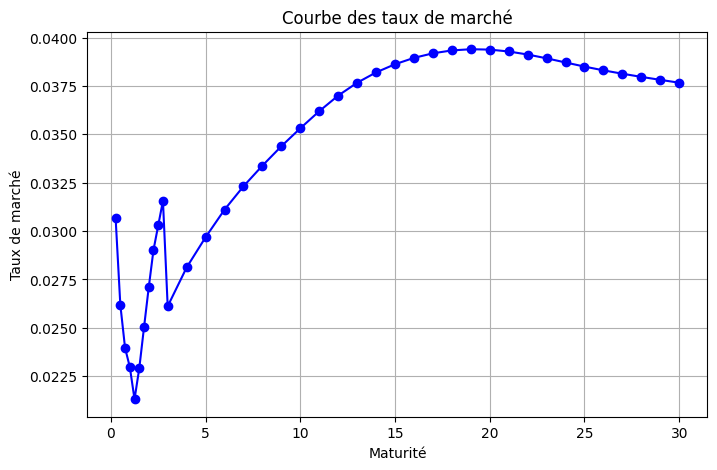

In [19]:
# Affichage d'une courbe homogène de taux de marché en fonction de la maturité
new_df = data.copy()
new_df['tx_h'] = new_df.apply(lambda x: 1 - x['tx'] if x['type'] == 'FUT' else x['tx'], axis=1)

plt.figure(figsize=(8, 5))
plt.plot(new_df["T"], new_df["tx_h"], marker='o', linestyle='-', color='b')
plt.xlabel('Maturité')
plt.ylabel('Taux de marché')
plt.title('Courbe des taux de marché')
plt.grid()
plt.show()

Le fait de disposer de cotations annuelles de taux de swap simplifie considérablement la procédure de bootstrap, car les dates de paiement du swap coïncident exactement avec les maturités déjà construites de la courbe zéro-coupon. À chaque étape, un seul facteur d’actualisation est inconnu et peut être déterminé de manière analytique, sans recourir à l’interpolation, ce qui renforce à la fois la stabilité numérique et la transparence économique de la courbe obtenue.

#### **Question 2**

**Extraction du taux zero coupon sur le segment Money Market**

Les taux zéro-coupon continus sont définis par la formule suivante :

$$
r(t,T) = -\frac{1}{T-t} \ln B(t,T),
$$

où B(t,T) est le facteur d'actualisation ($B(t,T) = exp(-r(t,T) \times  T)$ ), i.e. le prix d'une obligation zéro-coupon de maturité T à la date t.

Ils sont la brique de base pour la valorisation des produits dérivés et des obligations. De ce fait, nous allons essayer de reconstituer la courbe des taux zéro-coupon implicite à partir de la courbe des taux de marché à l'aide de la méthode du bootstrapping. Cette méthode consiste à calculer les taux zéro-coupon implicites à partir des taux de marché en utilisant la formule suivante selon le segment Money Market :

$$
L_0(0,\delta) = \frac{1}{\delta} \left( \frac{1}{B(0,\delta)} - 1 \right)
$$

De ce fait, le facteur d'actualisation est :
$$
B(0,\delta) = \frac{1}{1 + \delta L_0(0,\delta)}
$$


**Extraction du taux zero coupon sur le segment Future**

Sur le segment Future, on a :

$$
Future = 1 - L_0(T,T+\delta) = 1 - \frac{1}{\delta} \left( \frac{B(0,T)}{B(0,T+\delta)} - 1 \right)
$$

De ce fait, le facteur d'actualisation est :
$$
B(0,T+\delta) = \frac{B(0,T)}{1 + \delta (1- Future)}
$$


**Extraction du taux zero coupon sur le segment swap**

Pour le segment swap payeur, on a :

$$
Swap(t, T_0, T_n) = B(t, T_0)−B(t, T_n)−K ×lvl(t) = 0,
$$

avec K le taux fixe du swap qui fait que la PV du swap vaut 0 et $lvl(t)=\sum_{i=1}^{n} \delta_i B(t, T_i)$ le taux de marché à la maturité $T_n$. De ce fait, le facteur d'actualisation est :
$$
B(0,T_n) = \frac{1 - K \sum_{i=1}^{n-1} \delta_i B(0,T_i)}{1 + K}
$$

In [20]:
def bootstrap_zc(df: pd.DataFrame, fut_delta=0.25, swap_delta=1.0):
    """
    df must contain columns: type in {"MM","FUT","SWAP"}, T (float, in years), tx (float)
    Returns df with discount factors B(0,T) and continuous zero rates r_cont(0,T).
    """
    df = df.copy()
    df = df.sort_values("T").reset_index(drop=True)

    B = {}  # dictionary: maturity -> discount factor

    # --- helper: log-linear interpolation on discount factors (in ln B)
    def get_B(T):
        if T in B:
            return B[T]

        known_T = np.array(sorted(B.keys()))
        if T < known_T.min() or T > known_T.max():
            raise ValueError(f"Cannot interpolate B({T}): outside known range [{known_T.min()}, {known_T.max()}].")

        # find bracketing points
        j = np.searchsorted(known_T, T)
        T1, T2 = known_T[j - 1], known_T[j]
        lnB1, lnB2 = np.log(B[T1]), np.log(B[T2])

        w = (T - T1) / (T2 - T1)
        lnB = (1 - w) * lnB1 + w * lnB2
        return float(np.exp(lnB))

    # --- 1) Money Market
    for i, row in df[df["type"] == "MM"].iterrows():
        T = float(row["T"])
        L = float(row["tx"])
        # B(0,T) = 1 / (1 + T * L)
        B[T] = 1.0 / (1.0 + T * L)

    # --- 2) Futures (quarterly forward steps)
    for i, row in df[df["type"] == "FUT"].iterrows():
        T_next = float(row["T"])         # this row corresponds to maturity T+delta in your recursion
        Future = float(row["tx"])        # quoted future price ~ 0.97-0.98

        T_prev = T_next - fut_delta
        if T_prev <= 0:
            raise ValueError(f"Unexpected FUT maturity {T_next}: T_prev = {T_prev} <= 0.")

        if T_prev not in B:
            # if missing, interpolate from what we already have
            B_prev = get_B(T_prev)
        else:
            B_prev = B[T_prev]

        # L0(T_prev, T_next) = 1 - Future
        # B(0,T_next) = B(0,T_prev) / (1 + delta * L0)
        B[T_next] = B_prev / (1.0 + fut_delta * (1.0 - Future))

    # --- 3) Swaps (annual fixed leg, bootstrapped year by year)
    # We assume swaps are quoted at integer maturities and pay annually: T_i = 1,2,...,n
    swap_rows = df[df["type"] == "SWAP"]
    for i, row in swap_rows.iterrows():
        Tn = float(row["T"])
        K = float(row["tx"])

        n = int(round(Tn / swap_delta))
        if abs(Tn - n * swap_delta) > 1e-10:
            raise ValueError(f"Swap maturity T={Tn} is not aligned with swap_delta={swap_delta}.")

        # lvl = sum_{i=1}^{n} delta * B(0, i*delta)
        # Using your rearranged formula for annual swaps (delta=1):
        # B(0,Tn) = (1 - K * sum_{i=1}^{n-1} delta * B(0,Ti)) / (1 + K*delta_n)
        lvl_prev = 0.0
        for k in range(1, n):  # 1..n-1
            Ti = k * swap_delta
            Bi = B[Ti] if Ti in B else get_B(Ti)
            lvl_prev += swap_delta * Bi

        denom = 1.0 + K * swap_delta
        numer = 1.0 - K * lvl_prev
        B[Tn] = numer / denom

    # --- build output
    out = df.copy()
    out["B"] = out["T"].apply(lambda T: B[float(T)] if float(T) in B else get_B(float(T)))
    out["zc_cont"] = out.apply(lambda r: (-np.log(r["B"]) / r["T"]) if r["T"] > 0 else np.nan, axis=1)

    return out


In [21]:
data_zc = bootstrap_zc(data)
# Affichage
# data_zc[["type", "T", "tx", "B", "zc_cont"]]

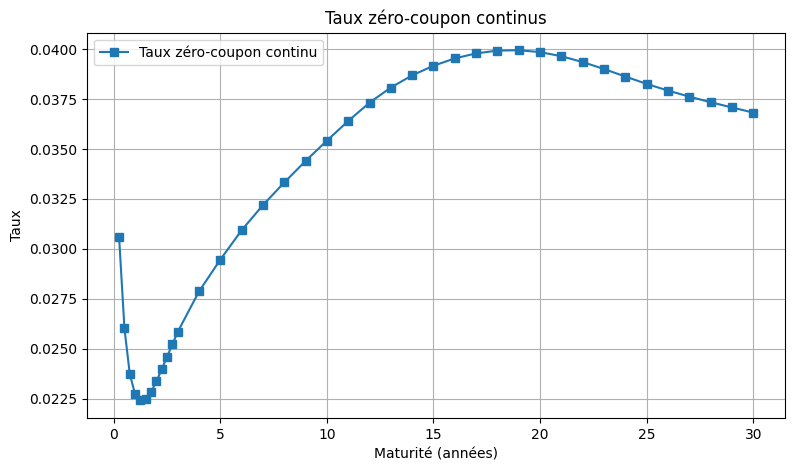

In [22]:
# Représentation des taux zéro coupon

plt.figure(figsize=(9, 5))

# Taux zéro-coupon continu
plt.plot(
    data_zc["T"],
    data_zc["zc_cont"],
    marker="s",
    linestyle="-",
    label="Taux zéro-coupon continu"
)

plt.xlabel("Maturité (années)")
plt.ylabel("Taux")
plt.title("Taux zéro-coupon continus")
plt.legend()
plt.grid(True)
plt.show()


#### **Question 3** :

Oui, le mode d’interpolation a un impact significatif sur le calcul des taux de marché car il affecte la forme de la courbe des taux et donc la valorisation des instruments financiers.

### 1.3. Construction de la courbe des taux forward

#### Courbe des taux forward

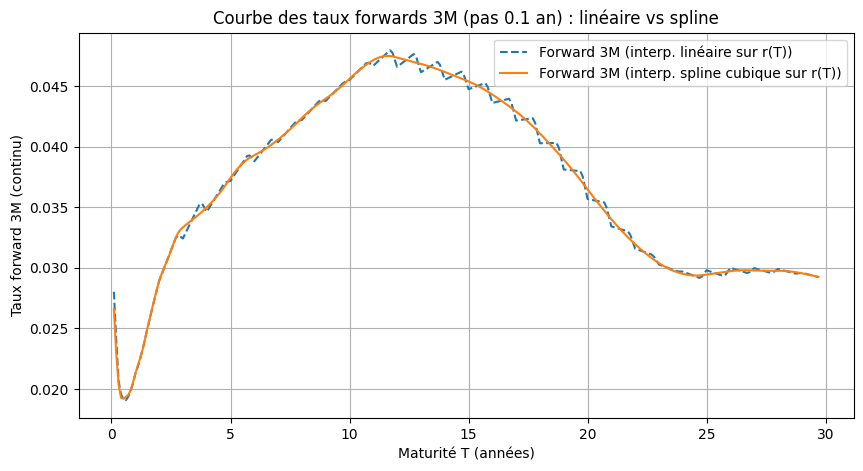

     T  fwd_3m_linear  fwd_3m_spline
0  0.1       0.028028       0.026600
1  0.2       0.024016       0.022928
2  0.3       0.020644       0.020367
3  0.4       0.019553       0.019269
4  0.5       0.019192       0.019192


In [ ]:
from scipy.interpolate import CubicSpline  # pip install scipy

def bootstrap_zc(df: pd.DataFrame, fut_delta=0.25, swap_delta=1.0):
    df = df.copy().sort_values("T").reset_index(drop=True)
    B = {}

    def get_B(T):
        if T in B:
            return B[T]
        known = np.array(sorted(B.keys()))
        j = np.searchsorted(known, T)
        T1, T2 = known[j-1], known[j]
        lnB1, lnB2 = np.log(B[T1]), np.log(B[T2])
        w = (T - T1) / (T2 - T1)
        return float(np.exp((1-w)*lnB1 + w*lnB2))

    # Money Market
    for _, row in df[df["type"] == "MM"].iterrows():
        T, L = float(row["T"]), float(row["tx"])
        B[T] = 1.0 / (1.0 + T * L)

    # Futures
    for _, row in df[df["type"] == "FUT"].iterrows():
        T_next = float(row["T"])
        Future = float(row["tx"])
        T_prev = T_next - fut_delta
        B_prev = B[T_prev] if T_prev in B else get_B(T_prev)
        B[T_next] = B_prev / (1.0 + fut_delta * (1.0 - Future))

    # Swaps (annuels)
    for _, row in df[df["type"] == "SWAP"].iterrows():
        Tn, K = float(row["T"]), float(row["tx"])
        n = int(round(Tn / swap_delta))
        lvl_prev = 0.0
        for k in range(1, n):  # 1..n-1
            Ti = k * swap_delta
            Bi = B[Ti] if Ti in B else get_B(Ti)
            lvl_prev += swap_delta * Bi
        B[Tn] = (1.0 - K * lvl_prev) / (1.0 + K * swap_delta)

    out = df.copy()
    out["B"] = out["T"].apply(lambda T: B[float(T)] if float(T) in B else get_B(float(T)))
    out["zc_cont"] = (-np.log(out["B"]) / out["T"])
    return out

df_zc = bootstrap_zc(data)


# 2) Forwards 3M sur une grille de pas 0.1 : interp linéaire vs spline
delta = 0.25
dt_grid = 0.1

nodes = df_zc[["T", "zc_cont"]].dropna().sort_values("T")
T_nodes = nodes["T"].to_numpy(float)
r_nodes = nodes["zc_cont"].to_numpy(float)

T_max = float(T_nodes.max())
T_grid = np.arange(dt_grid, T_max - delta + 1e-12, dt_grid)

def B_from_r(T, r):
    return np.exp(-r * T)

# A) interpolation linéaire sur r(T)
r_lin_T = np.interp(T_grid, T_nodes, r_nodes)
r_lin_Td = np.interp(T_grid + delta, T_nodes, r_nodes)
B_lin_T  = B_from_r(T_grid, r_lin_T)
B_lin_Td = B_from_r(T_grid + delta, r_lin_Td)
fwd_lin = (1.0 / delta) * np.log(B_lin_T / B_lin_Td)

# B) interpolation spline cubique "natural" sur r(T)
cs = CubicSpline(T_nodes, r_nodes, bc_type="natural")
r_spl_T  = cs(T_grid)
r_spl_Td = cs(T_grid + delta)
B_spl_T  = B_from_r(T_grid, r_spl_T)
B_spl_Td = B_from_r(T_grid + delta, r_spl_Td)
fwd_spl = (1.0 / delta) * np.log(B_spl_T / B_spl_Td)

# 3) Graphique illustré : forwards 3M

plt.figure(figsize=(10, 5))
plt.plot(T_grid, fwd_lin, label="Forward 3M (interp. linéaire sur r(T))", linestyle="--")
plt.plot(T_grid, fwd_spl, label="Forward 3M (interp. spline cubique sur r(T))", linestyle="-")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux forward 3M (continu)")
plt.title("Courbe des taux forwards 3M (pas 0.1 an) : linéaire vs spline")
plt.grid(True)
plt.legend()
plt.show()

# Comparaison rapide
df_fwd = pd.DataFrame({"T": T_grid, "fwd_3m_linear": fwd_lin, "fwd_3m_spline": fwd_spl})
print(df_fwd.head())


#### **Question 2** 
Shifter le taux de swap 5Y de 10 bps. Expliquer l’impact sur les courbes des taux zéro-coupon et forward.
Comparer les deux méthodes d’interpolation linaire et par spline. A quoi sont dus ces écarts ?

In [24]:
# +10 basis points = +0.0010
bump = 10 / 10000

df_bump = data.copy()

df_bump.loc[
    (df_bump["type"] == "SWAP") & (df_bump["T"] == 5.0),
    "tx"
] += bump

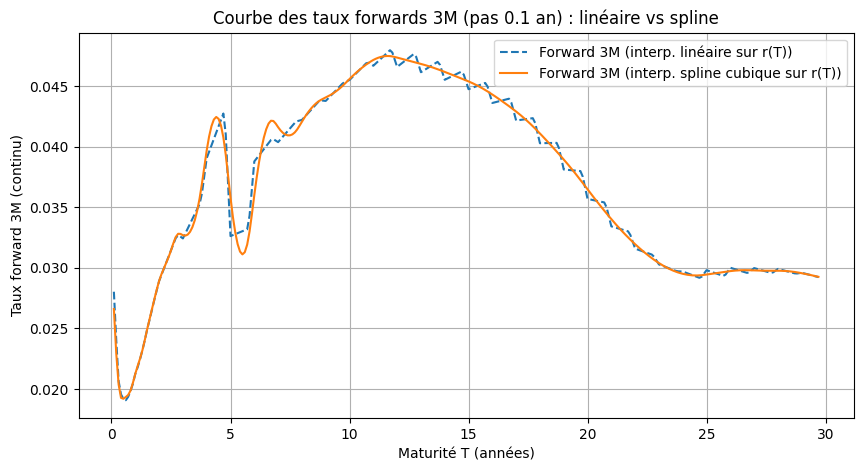

     T  fwd_3m_linear  fwd_3m_spline
0  0.1       0.028028       0.026600
1  0.2       0.024016       0.022928
2  0.3       0.020644       0.020367
3  0.4       0.019553       0.019269
4  0.5       0.019192       0.019192


In [25]:
df_zc = bootstrap_zc(df_bump)

# 2) Forwards 3M sur une grille de pas 0.1 : interp linéaire vs spline
delta = 0.25
dt_grid = 0.1

nodes = df_zc[["T", "zc_cont"]].dropna().sort_values("T")
T_nodes = nodes["T"].to_numpy(float)
r_nodes = nodes["zc_cont"].to_numpy(float)

T_max = float(T_nodes.max())
T_grid = np.arange(dt_grid, T_max - delta + 1e-12, dt_grid)

def B_from_r(T, r):
    return np.exp(-r * T)

# A) interpolation linéaire sur r(T)
r_lin_T = np.interp(T_grid, T_nodes, r_nodes)
r_lin_Td = np.interp(T_grid + delta, T_nodes, r_nodes)
B_lin_T  = B_from_r(T_grid, r_lin_T)
B_lin_Td = B_from_r(T_grid + delta, r_lin_Td)
fwd_lin = (1.0 / delta) * np.log(B_lin_T / B_lin_Td)

# B) interpolation spline cubique "natural" sur r(T)
cs = CubicSpline(T_nodes, r_nodes, bc_type="natural")
r_spl_T  = cs(T_grid)
r_spl_Td = cs(T_grid + delta)
B_spl_T  = B_from_r(T_grid, r_spl_T)
B_spl_Td = B_from_r(T_grid + delta, r_spl_Td)
fwd_spl = (1.0 / delta) * np.log(B_spl_T / B_spl_Td)

# 3) Graphique illustré : forwards 3M

plt.figure(figsize=(10, 5))
plt.plot(T_grid, fwd_lin, label="Forward 3M (interp. linéaire sur r(T))", linestyle="--")
plt.plot(T_grid, fwd_spl, label="Forward 3M (interp. spline cubique sur r(T))", linestyle="-")
plt.xlabel("Maturité T (années)")
plt.ylabel("Taux forward 3M (continu)")
plt.title("Courbe des taux forwards 3M (pas 0.1 an) : linéaire vs spline")
plt.grid(True)
plt.legend()
plt.show()

# Comparaison rapide
df_fwd = pd.DataFrame({"T": T_grid, "fwd_3m_linear": fwd_lin, "fwd_3m_spline": fwd_spl})
print(df_fwd.head())
